# <u>**Exploratory Data Analysis (EDA)**</u>

A descriptive analysis explores the underlying structure for the ACE National Lottery Project Grants awarded in 2023-2024 and 2025-2026. Patterns reveal connections to answer questions the hypothesis raises in the README. The purpose of this notebook is to:

- Provide an overview on descriptive statistics. 

- Explore distributions of award amount across ace areas, main diciplines and strands. 

- Display value counts for categorical variables.

- Investigate potential outliers or anomilies. 

- Test hypotheis. 

- Identify patterns to inform modelling decisions.

Additional libraries to visualise numbers are included in this notebook, which will also inform dashboard decision to share discoveries in this notebook for non-technical stakeholders.  

</b>

## <u>**Load Libraries and Data**</u>

Libraries - Pandas, Numpy, Matplotlib and Seaborn - are imported. Cleaned data CSV file is loaded into a DataFrame using Pandas.

In [10]:
# Import libraries
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data
df_combined = pd.read_csv('/Users/admin/Documents/Code Institute/ace_project/data/clean/cleaned_data.csv')

# Display the first few rows of the DataFrame
df_combined.head()

,award_amount,award_date,decision_month,decision_quarter,ace_area,local_authority,main_discipline,strand,time_limited_priority,award_year
0,27689,2023-04-03,April,Q1,South West,"Bournemouth, Christchurch and Poole",Music,"£30,000 and below",Supporting Grassroots Live Music,2023
1,29623,2023-04-03,April,Q1,South West,Portsmouth,Theatre,"£30,000 and below",Not Time-Limited Priority,2023
2,25256,2023-04-03,April,Q1,South West,Bath and North East Somerset,Combined arts,"£30,000 and below",Not Time-Limited Priority,2023
3,30500,2023-04-03,April,Q1,South West,"Bristol, City of",Visual arts,"£30,000 and below",Not Time-Limited Priority,2023
4,20060,2023-04-03,April,Q1,South West,South Gloucestershire,Theatre,"£30,000 and below",Not Time-Limited Priority,2023


In [9]:
print("Dataframe shape:", df_combined.shape)
df_combined.info()

Dataframe shape: (5454, 10)
<class 'pandas.DataFrame'>
RangeIndex: 5454 entries, 0 to 5453
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   award_amount           5454 non-null   int64
 1   award_date             5454 non-null   str  
 2   decision_month         5454 non-null   str  
 3   decision_quarter       5454 non-null   str  
 4   ace_area               5454 non-null   str  
 5   local_authority        5454 non-null   str  
 6   main_discipline        5454 non-null   str  
 7   strand                 5454 non-null   str  
 8   time_limited_priority  5454 non-null   str  
 9   award_year             5454 non-null   int64
dtypes: int64(2), str(8)
memory usage: 426.2 KB


</b>

## <u>**Statistical Overview**</u>

Use <code>.describe()</code> to provide an overview of the statistical summary for the numeric variables in the combined data. This is an intial step to understand the distribution for numeric variables and identify potential outliers that may require further investigation. 

In [11]:
# Display summary statistics for numerical columns
df_combined.describe()

,award_amount,award_year
count,5.454000e+03,5454.000000
mean,4.068841e+04,2024.189952
std,7.853711e+04,1.161237
min,0.000000e+00,2023.000000
25%,1.939175e+04,2023.000000
50%,2.940650e+04,2024.000000
75%,3.471500e+04,2025.000000
max,2.019149e+06,2026.000000


The <code>year</code> column behaves as expected for year-to-year comparisions.  

Meanwhile, <code>award_amount</code> presents a different set of numbers:

**Count** - (5454) this number confirms there are no missing values and a value in each row for the award amount column.

**Mean** - (40688.41...) the average award amount is £40,688. 

**Std** - (78537.10...) there is high variance in award amount size. 

**Min** - (0) zero is unexpected and demands an additional investigation. 

**25%** - (19391.75) the first quarter of award amounts are below £19,391. 

**50%** - (29406.5) the median size of awards is £29,406.  

**75%** - (34715.0) three quarters of award amounts cluster below £34,715.

**Max** - (2019149.0) the maximum award is £2,019,149.

Inevitably the minimum and maximum award amounts are skewing the mean, standard deviation and quartile results. The mean (£40,688) is above the median (£29,406) because there are a few high award amounts such as the maximum reaching (£2,019,149). Model performance may also be impacted without considering and applying an appropiate scaling method.



</b>

## **<u>Univariate Analysis (Numeric)</u>**

Examine <code>award_amount</code> distribution, spread, skewness and outliers to understand scaling methods required for improving model performance. 

### **Award Amount Distribution**

Plot a histogram to visualise the distribution of mean, median and mode for <code>award_amount</code>. Code modified by in-built Copilot to improve UX design. 

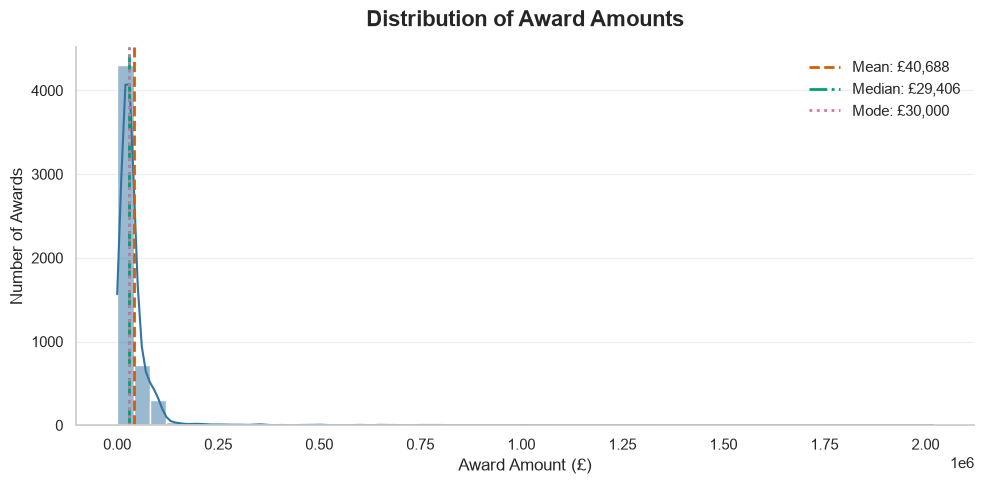

In [ ]:
# Set the visual style for all plots in the notebook
sns.set_theme(style="whitegrid", context="notebook")

# Drop any missing values from the award_amount column to analyse valid data only
amounts = df_combined["award_amount"].dropna()

# Calculate the average award amount
mean_amount = amounts.mean()

# Calculate the median award amount
median_amount = amounts.median()

# Calculate the most frequent award amount(s)
mode_amounts = amounts.mode()

# Create a figure and axis for the chart
fig, ax = plt.subplots(figsize=(10, 5))

# Plot a histogram of award amounts with a kernel density estimate overlay
sns.histplot(
    x=amounts,                 # Data to plot
    bins=50,                   # Number of histogram bins
    kde=True,                  # Show the KDE curve
    color="#3274A1",         # Histogram bar colour
    edgecolor="white",         # Outline colour for bars
    ax=ax                      # Plot on the current axis
)

# Add a dashed vertical line showing the mean award amount
ax.axvline(
    mean_amount,               # X-position of the mean line
    color="#D55E00",         # Colour of the line
    linestyle="--",            # Dashed line style
    linewidth=2,               # Line thickness
    label=f"Mean: £{mean_amount:,.0f}"  # Label to display in legend
)

# Add a dash-dot vertical line showing the median award amount
ax.axvline(
    median_amount,             # X-position of the median line
    color="#009E73",         # Colour of the line
    linestyle="-.",            # Dash-dot line style
    linewidth=2,               # Line thickness
    label=f"Median: £{median_amount:,.0f}"  # Label to display in legend
)

# Add a dotted vertical line for each mode value
for mode_value in mode_amounts:
    ax.axvline(
        mode_value,            # X-position of the mode line
        color="#CC79A7",     # Colour of the mode line
        linestyle=":",         # Dotted line style
        linewidth=2,           # Line thickness
        label=f"Mode: £{mode_value:,.0f}"  # Label to display in legend
    )

# Set the chart title
ax.set_title("Distribution of Award Amounts", fontsize=16, weight="bold", pad=15)

# Label the x-axis
ax.set_xlabel("Award Amount (£)")

# Label the y-axis
ax.set_ylabel("Number of Awards")

# Display the legend without a surrounding frame
ax.legend(frameon=False)

# Add horizontal gridlines for readability
ax.grid(axis="y", alpha=0.3)

# Hide vertical gridlines
ax.grid(axis="x", visible=False)

# Remove the top and right spines for a cleaner appearance
sns.despine()

# Adjust the layout to prevent labels and title from being cut off
plt.tight_layout()

# Display the final plot
plt.show()


The mean (£4,688) is higher than both the median (£29,406) and the mode (£30,000). Distribution is positively skewed to the right with a long tail meaning most awards are relatively small, whilst an even smaller number of very large award amounts pull the mean upwards. Thus, the median indicates the most typical award amount because it is not distorted by outliers. 

An unexpected minimum value (£0) is present, which may imply a data quality issue to inspect in the *Outlier Inspection* section. 